# 3H - Genese: o que separa as classes NOAA de El Nino?

**Pergunta especifica.** Que valores as variaveis assumem antes do onset dos eventos NOAA/ONI locais, e o estado precursor separa `fraco`, `moderado`, `forte` e `muito_forte`?

**Objetivo.** Compostos alinhados ao ONSET e ordenamento da intensidade final usando a classificacao NOAA baseada no pico da media movel de 3 meses.

**Justificativa.** A classificacao por percentis foi descartada. A genese deve comparar os niveis oficiais de intensidade e manter a media geral apenas como storyline fisico auxiliar.

**Metodologia.** Eventos = media movel 3 meses >=+0.5 C por 5+ estacoes sobrepostas. Compostos -52..+78 semanas do onset por classe NOAA; estado precursor em -26/-13/0 semanas; Spearman(estado precursor -26..0, intensidade final). **Area:** caixa Nino 3.4; WWV no Pacifico equatorial.

**Saidas.** `phase3H_proveniencia_eventos.csv`, `phase3H_compostos_onset.csv`, `phase3H_grupos_classes_noaa.csv`, `phase3H_estado_precursor_por_classe.csv`, `phase3H_separacao_genese.csv`, `phase3H_fases_ciclo_vida.csv`, `phase3H_ciclo_vida_media.csv` + compostos e ciclo de vida com fases mapeadas.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev=u.events_noaa().copy()
prov=ev[['event_id','classe_noaa','event_start','peak_time','event_end','duration_oni_seasons','peak_oni_local_c','peak_monthly_ssta_c']].copy()
prov.columns=['evento','classe','onset','pico','fim','duracao_estacoes_oni','oni_pico_c','ssta_mensal_pico_c']
u.save_table(prov,'phase3H_proveniencia_eventos.csv',index=False)
counts=prov['classe'].value_counts().to_dict()
print('PROVENIENCIA NOAA/ONI local - '+', '.join(f'{k} n={counts.get(k,0)}' for k in u.ELNINO_MEAN_GROUP_ORDER))
print(prov[['evento','classe','onset']].to_string(index=False))


[tabela] data\processed\parquet\statistics\phase3H_proveniencia_eventos.csv
PROVENIENCIA NOAA/ONI local - fraco n=4, moderado n=2, forte n=3, muito_forte n=3
                 evento      classe      onset
el_nino_oisst_1982_1983 muito_forte 1982-07-01
el_nino_oisst_1986_1988    moderado 1986-10-01
el_nino_oisst_1991_1992       forte 1991-09-01
el_nino_oisst_1994_1995       fraco 1994-10-01
el_nino_oisst_1997_1998 muito_forte 1997-06-01
el_nino_oisst_2002_2003    moderado 2002-07-01
     el_nino_oisst_2004       fraco 2004-08-01
el_nino_oisst_2006_2007       fraco 2006-09-01
el_nino_oisst_2009_2010       forte 2009-07-01
el_nino_oisst_2014_2016 muito_forte 2014-10-01
el_nino_oisst_2018_2019       fraco 2018-10-01
el_nino_oisst_2023_2024       forte 2023-05-01


[tabela] data\processed\parquet\statistics\phase3H_grupos_classes_noaa.csv


[figura] data\processed\figures\fase3\3H1_compostos_onset.png


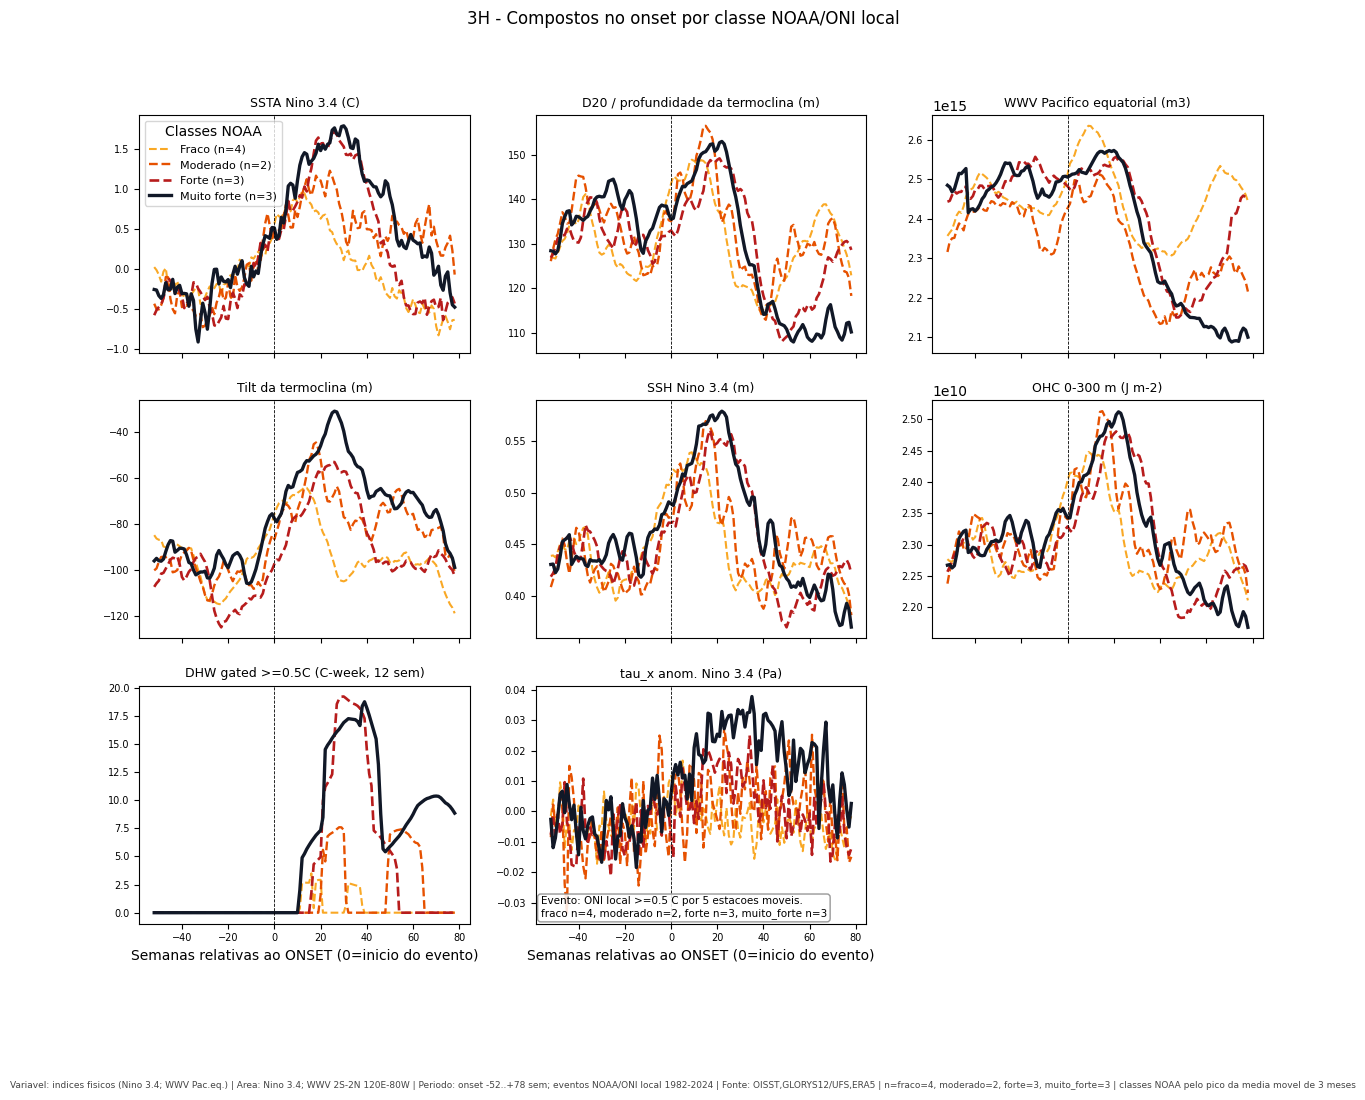

In [2]:
VARS=['nino34_ssta','d20_m','wwv','tilt_m','ssh_m','ohc_0_300','dhw_cweek_0p5_12w','tau_x_anom_nino34_pa']; LAGS=list(range(-52,79))
def onset_al(s,o):
    i=s.index.get_indexer([o],method='nearest')[0]; seg=s.iloc[max(0,i-52):i+79]
    rel=((seg.index-s.index[i]).days/7).round().astype(int); return pd.Series(seg.values,index=rel).reindex(LAGS)
groups=u.elnino_mean_groups(ev)
comps={g:pd.DataFrame({v:pd.DataFrame([onset_al(w[v],e.event_start) for _,e in gg.iterrows()]).mean() for v in VARS}) for g,gg in groups.items() if len(gg)>0}
comps['todos_elnino_noaa']=pd.DataFrame({v:pd.DataFrame([onset_al(w[v],e.event_start) for _,e in ev.iterrows()]).mean() for v in VARS})
pd.concat({g:v for g,v in comps.items() if g!='todos_elnino_noaa'},names=['grupo','sem_rel_onset']).to_csv(u.STATS/'phase3H_compostos_onset.csv')
u.save_table(u.elnino_mean_group_table()[['grupo','rotulo','definicao']],'phase3H_grupos_classes_noaa.csv',index=False)
fig,axes=plt.subplots(3,3,figsize=(14.5,10.5),sharex=True)
for ax,v in zip(axes.flat,VARS):
    for g in u.ELNINO_MEAN_GROUP_ORDER:
        if g in comps:
            meta=u.elnino_group_style(g)
            ax.plot(LAGS,comps[g][v],color=meta['color'],label=f"{meta['rotulo_curto']} (n={len(groups[g])})",lw=meta['linewidth'],ls=meta['linestyle'])
    ax.axvline(0,color='k',ls='--',lw=.6); ax.set_title(u.var_label(v),fontsize=9); ax.tick_params(labelsize=7)
axes.flat[0].legend(fontsize=8,title='Classes NOAA')
for ax in axes[-1]: ax.set_xlabel('Semanas relativas ao ONSET (0=inicio do evento)')
for ax in axes.flat[len(VARS):]: ax.axis('off')
counts=ev['classe_noaa'].value_counts().to_dict()
fig.suptitle('3H - Compostos no onset por classe NOAA/ONI local')
u.add_note(axes.flat[-2], 'Evento: ONI local >=0.5 C por 5 estacoes moveis.\n' + ', '.join(f'{k} n={counts.get(k,0)}' for k in u.ELNINO_MEAN_GROUP_ORDER), loc='lower left')
u.stamp_caption(fig,variavel='indices fisicos (Nino 3.4; WWV Pac.eq.)',area='Nino 3.4; WWV 2S-2N 120E-80W',periodo='onset -52..+78 sem; eventos NOAA/ONI local 1982-2024',fonte='OISST,GLORYS12/UFS,ERA5',n=', '.join(f"{k}={counts.get(k,0)}" for k in u.ELNINO_MEAN_GROUP_ORDER),extra='classes NOAA pelo pico da media movel de 3 meses')
u.save_fig(fig,'3H1_compostos_onset.png'); plt.show()


[tabela] data\processed\parquet\statistics\phase3H_fases_ciclo_vida.csv
[tabela] data\processed\parquet\statistics\phase3H_ciclo_vida_media.csv


[figura] data\processed\figures\fase3\3H2_ciclo_vida.png


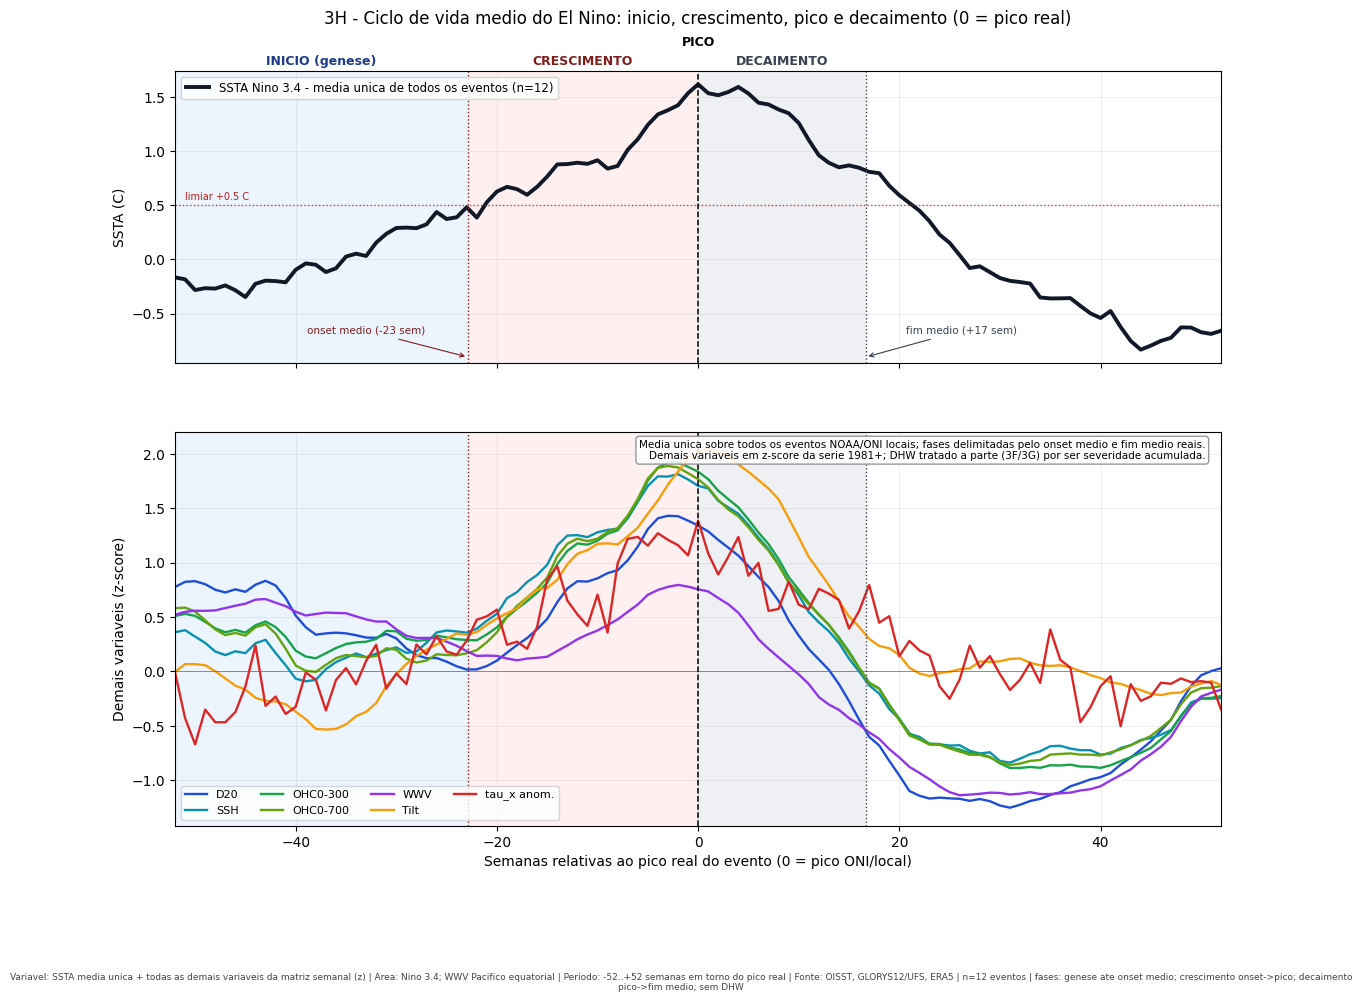

In [3]:
# Ciclo de vida MEDIO alinhado ao pico real, com as fases mapeadas no grafico:
# inicio (genese) -> crescimento -> pico -> decaimento. Uma UNICA media para a
# SSTA Nino 3.4 (todos os eventos NOAA/ONI locais) e TODAS as demais variaveis
# da matriz semanal em z-score. DHW removido desta leitura (severidade
# acumulada, nao dinamica de ciclo - ver 3F/3G).
VARS_Z = ['d20_m','ssh_m','ohc_0_300','ohc_0_700','wwv','tilt_m','tau_x_anom_nino34_pa']
REL = list(range(-52, 53))

def peak_al(s, peak):
    i = s.index.get_indexer([peak], method='nearest')[0]
    seg = s.iloc[max(0, i-52):i+53]
    rel = ((seg.index - s.index[i]).days/7).round().astype(int)
    return pd.Series(seg.values, index=rel).reindex(REL)

ssta_comp = pd.DataFrame([peak_al(w['nino34_ssta'], e.peak_time) for _, e in ev.iterrows()]).mean()
zcomp = {}
for v in VARS_Z:
    z = (w[v] - w[v].mean()) / w[v].std()
    zcomp[v] = pd.DataFrame([peak_al(z, e.peak_time) for _, e in ev.iterrows()]).mean()

# fases medias derivadas dos proprios eventos (semanas relativas ao pico real)
onset_off = float(np.mean([(e.event_start - e.peak_time).days/7 for _, e in ev.iterrows()]))
end_off = float(np.mean([(e.event_end - e.peak_time).days/7 for _, e in ev.iterrows()]))
fases = pd.DataFrame([
    {'fase':'inicio (genese)','de_sem':-52,'ate_sem':round(onset_off,1),'criterio':'antes do onset medio (ONI local cruza +0.5 C)'},
    {'fase':'crescimento','de_sem':round(onset_off,1),'ate_sem':0,'criterio':'do onset medio ate o pico real'},
    {'fase':'pico','de_sem':0,'ate_sem':0,'criterio':'semana 0 = pico da media movel de 3 meses'},
    {'fase':'decaimento','de_sem':0,'ate_sem':round(end_off,1),'criterio':'do pico ate o fim medio do evento'},
])
u.save_table(fases,'phase3H_fases_ciclo_vida.csv',index=False)
tab = pd.DataFrame({'semana_rel_pico':REL,'ssta_media_c':ssta_comp.values, **{f'{v}_z':zcomp[v].values for v in VARS_Z}})
tab['n_eventos'] = len(ev)
u.save_table(tab,'phase3H_ciclo_vida_media.csv',index=False)

CORES = {'d20_m':'#1d4ed8','ssh_m':'#0891b2','ohc_0_300':'#16a34a','ohc_0_700':'#65a30d','wwv':'#9333ea','tilt_m':'#f59e0b','tau_x_anom_nino34_pa':'#dc2626'}
fig, axes = plt.subplots(2, 1, figsize=(13.5, 9.8), sharex=True, gridspec_kw={'height_ratios':[1, 1.35]})
axes[0].plot(REL, ssta_comp.values, color='#111827', lw=2.8, label=f'SSTA Nino 3.4 - media unica de todos os eventos (n={len(ev)})')
axes[0].axhline(0.5, color='#b91c1c', ls=':', lw=1, alpha=.8)
axes[0].text(-51, 0.55, 'limiar +0.5 C', fontsize=7, color='#b91c1c')
axes[0].set_ylabel('SSTA (C)')
axes[0].legend(fontsize=8.5, loc='upper left')
for v in VARS_Z:
    axes[1].plot(REL, zcomp[v].values, color=CORES[v], lw=1.7, label=u.var_label(v, short=True))
axes[1].axhline(0, color='0.4', lw=.5)
axes[1].set_ylabel('Demais variaveis (z-score)')
axes[1].set_xlabel('Semanas relativas ao pico real do evento (0 = pico ONI/local)')
axes[1].legend(fontsize=8, ncol=4, loc='lower left')
for ax in axes:
    ax.axvspan(-52, onset_off, color='#dbeafe', alpha=.5, lw=0)
    ax.axvspan(onset_off, 0, color='#fee2e2', alpha=.5, lw=0)
    ax.axvspan(0, end_off, color='#e5e7eb', alpha=.6, lw=0)
    ax.axvline(0, color='k', ls='--', lw=1.1)
    ax.axvline(onset_off, color='#7f1d1d', ls=':', lw=1)
    ax.axvline(end_off, color='#374151', ls=':', lw=1)
    ax.grid(alpha=.2)
    ax.set_xlim(-52, 52)
trans = axes[0].get_xaxis_transform()
axes[0].text((-52+onset_off)/2, 1.02, 'INICIO (genese)', transform=trans, ha='center', fontsize=9, color='#1e3a8a', weight='bold')
axes[0].text(onset_off/2, 1.02, 'CRESCIMENTO', transform=trans, ha='center', fontsize=9, color='#7f1d1d', weight='bold')
axes[0].text(0, 1.085, 'PICO', transform=trans, ha='center', fontsize=9, color='k', weight='bold')
axes[0].text(end_off/2, 1.02, 'DECAIMENTO', transform=trans, ha='center', fontsize=9, color='#374151', weight='bold')
axes[0].annotate(f'onset medio ({onset_off:.0f} sem)', xy=(onset_off, 0.02), xycoords=trans, xytext=(onset_off-16, 0.10), textcoords=trans, fontsize=7.5, color='#7f1d1d', arrowprops={'arrowstyle':'->','color':'#7f1d1d','lw':.8})
axes[0].annotate(f'fim medio (+{end_off:.0f} sem)', xy=(end_off, 0.02), xycoords=trans, xytext=(end_off+4, 0.10), textcoords=trans, fontsize=7.5, color='#374151', arrowprops={'arrowstyle':'->','color':'#374151','lw':.8})
axes[0].set_title('3H - Ciclo de vida medio do El Nino: inicio, crescimento, pico e decaimento (0 = pico real)', pad=34)
u.add_note(axes[1], 'Media unica sobre todos os eventos NOAA/ONI locais; fases delimitadas pelo onset medio e fim medio reais.\nDemais variaveis em z-score da serie 1981+; DHW tratado a parte (3F/3G) por ser severidade acumulada.', loc='upper right')
u.stamp_caption(fig, variavel='SSTA media unica + todas as demais variaveis da matriz semanal (z)', area='Nino 3.4; WWV Pacifico equatorial', periodo='-52..+52 semanas em torno do pico real', fonte='OISST, GLORYS12/UFS, ERA5', n=f'{len(ev)} eventos', extra='fases: genese ate onset medio; crescimento onset->pico; decaimento pico->fim medio; sem DHW')
u.save_fig(fig, '3H2_ciclo_vida.png')
plt.show()

In [4]:
from scipy.stats import spearmanr
marcos=[-26,-13,0]; rows=[]
for g,gg in ev.groupby('classe_noaa'):
    for v in VARS:
        vals={m:[] for m in marcos}
        for _,e in gg.iterrows():
            s=onset_al(w[v],e.event_start)
            for m in marcos: vals[m].append(s.loc[m-2:m+2].mean())
        row={'classe':g,'variavel':v}
        for m in marcos:
            a=pd.Series(vals[m]).dropna(); row[f'media_{m}s']=round(a.mean(),3); row[f'range_{m}s']=f'{a.min():.2f}..{a.max():.2f}'
        rows.append(row)
u.save_table(pd.DataFrame(rows),'phase3H_estado_precursor_por_classe.csv',index=False)
rows=[]
for v in VARS:
    pre=[];it=[]
    for _,e in ev.iterrows():
        s=onset_al(w[v],e.event_start); pre.append(s.loc[-26:0].mean()); it.append(e.peak_oni_local_c if 'peak_oni_local_c' in e else e.peak_ssta_c)
    m=pd.notna(pre); rho,p=spearmanr(pd.Series(pre)[m],pd.Series(it)[m])
    rows.append({'variavel':v,'spearman_rho':round(float(rho),3),'p_bruto':round(float(p),3),'n':int(m.sum())})
sep=pd.DataFrame(rows).sort_values('spearman_rho',key=abs,ascending=False); u.save_table(sep,'phase3H_separacao_genese.csv',index=False)
print('SEPARACAO NA GENESE (Spearman estado precursor -26..0 vs pico ONI local; eventos NOAA):')
for _,r in sep.iterrows(): print(f"  {r.variavel:24s} rho={r.spearman_rho:+.2f} (p={r.p_bruto:.2f})")


[tabela] data\processed\parquet\statistics\phase3H_estado_precursor_por_classe.csv
[tabela] data\processed\parquet\statistics\phase3H_separacao_genese.csv
SEPARACAO NA GENESE (Spearman estado precursor -26..0 vs pico ONI local; eventos NOAA):
  d20_m                    rho=+0.55 (p=0.07)
  ohc_0_300                rho=+0.34 (p=0.28)
  wwv                      rho=+0.28 (p=0.38)
  tilt_m                   rho=+0.22 (p=0.50)
  ssh_m                    rho=+0.19 (p=0.56)
  tau_x_anom_nino34_pa     rho=+0.14 (p=0.67)
  nino34_ssta              rho=+0.06 (p=0.85)
  dhw_cweek_0p5_12w        rho=+nan (p=nan)


C:\Users\thiag\AppData\Local\Temp\ipykernel_29260\662807509.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  m=pd.notna(pre); rho,p=spearmanr(pd.Series(pre)[m],pd.Series(it)[m])


**Leitura do 3H.** A genese compara as classes NOAA/ONI local no onset (`3H1_compostos_onset.png`), e o ciclo de vida (`3H2_ciclo_vida.png`) agora mapeia explicitamente as quatro fases - **inicio (genese), crescimento, pico e decaimento** - delimitadas pelo onset medio e fim medio reais dos 12 eventos. A SSTA Nino 3.4 entra como **uma unica media** de todos os eventos; todas as demais variaveis da matriz semanal (D20, SSH, OHC 0-300/0-700, WWV, tilt e tau_x_anom) aparecem em z-score para comparacao direta. O DHW foi retirado desta leitura por ser severidade acumulada (integrador posterior ao pico; ver 3F/3G), nao dinamica de ciclo. O bloco de recarga/subsuperficie cresce antes e junto da SSTA e descarrega apos o pico; `tau_x_anom` acompanha o acoplamento no crescimento.